# Model Project

**Yuki Matsushima**

## Table of Content
### Introduction

### Set Up and Imports

### 1. Labor Supply
**1.1 Numerical Optimizer vs Root-Finders** \
**1.2 Labor Supply Function** 

### 2. Public Goods
**2.1 Tax Revenue and Socoal Welfare Function** \
**2.2 Optimal Tax System**

### 3. Top Tax
**3.1 Labor Supply** \
**3.2 Labor Supply Function** \
**3.3 Public Good**

### Extention Analysis

## Introduction
This project studies how individual labor supply choices interact with government taxation and public good provision in a simple economic model. Each worker chooses how many hours to supply by balancing the benefits of consumption against the disutility of working. Taxes reduce the return to labor, while lump-sum taxes or transfers shift disposable income in a way that affects incentives differently. By solving workers’ decisions both with a numerical optimizer and through first-order conditions, the project shows how different numerical methods can be used to analyze the same economic problem.

At the aggregate level, the government collects revenue from a population of workers whose productivities follow a log-normal distribution. This revenue is converted into a public good that contributes to social welfare. By simulating the economy for different combinations of tax rates and lump-sum components, we compute tax revenue, social welfare, and ultimately identify the tax system that maximizes welfare. The project also evaluates how taxes affect inequality through Lorenz curves.

Finally, we extend the model to include a top tax bracket with a kinked budget constraint to examine how additional tax progressivity influences labor supply, revenue, and welfare. Overall, the project links micro-level behavior to macro-level policy outcomes using numerical tools.

## Set Up and Import

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from Worker import WorkerClass   
from Government import GovernmentClass
from scipy import optimize
from scipy.optimize import minimize_scalar
from scipy.optimize import root_scalar
import time

## 1. Labor Supply

### 1.1 Optimizer vs Root-Finders

In [4]:
worker = WorkerClass()  # baseline parameters

p = 1.0
ell_grid = np.linspace(0.5, worker.par.ell_max, 200)
eps_list = [1.0, 0.75, 0.50]

results = []


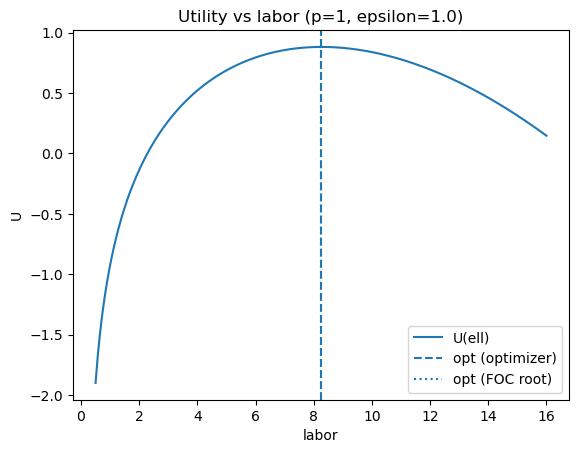

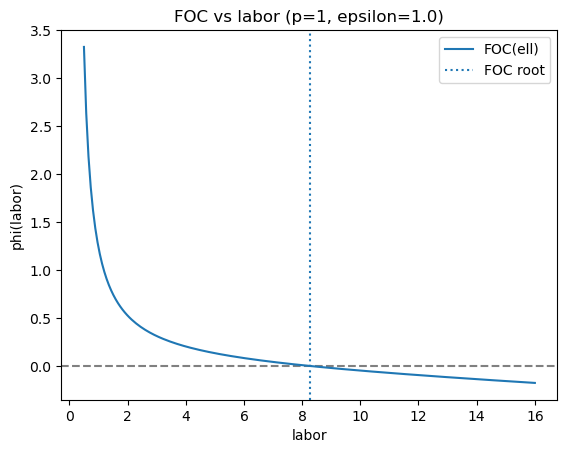

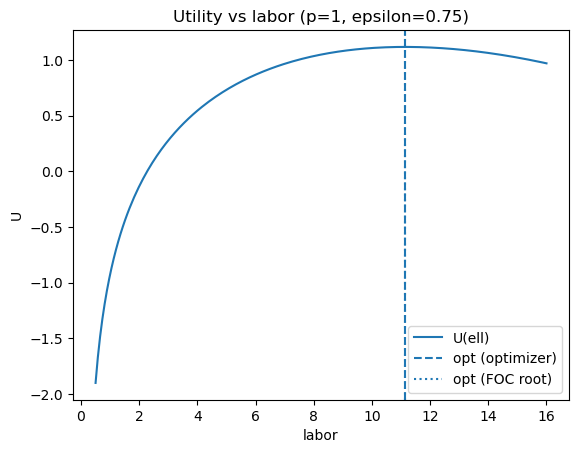

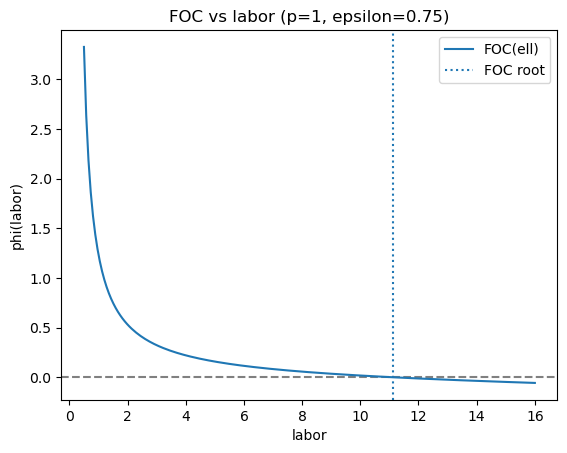

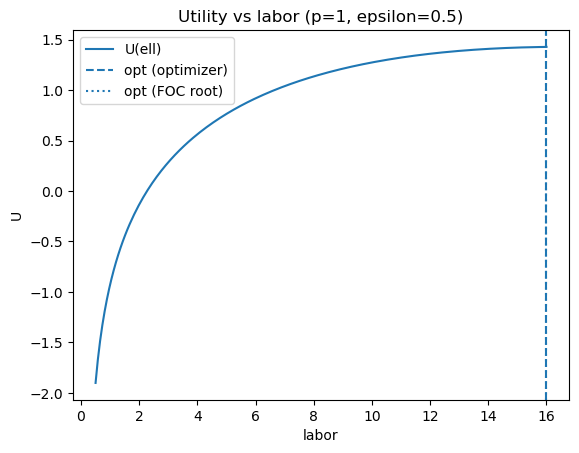

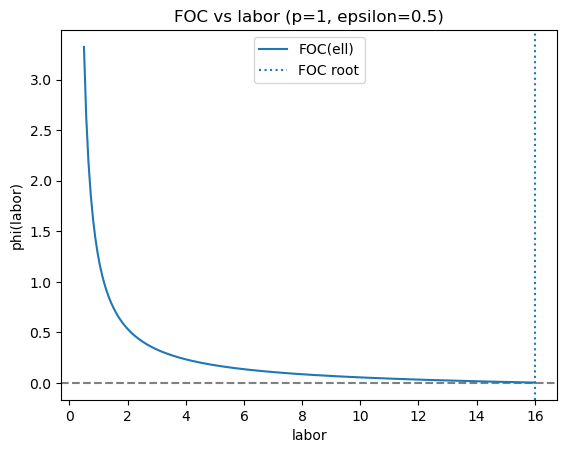

epsilon=1.00: ell* optimizer=8.2656, ell* FOC=8.2656 | time optimizer=0.23 ms, time FOC=0.08 ms
epsilon=0.75: ell* optimizer=11.1360, ell* FOC=11.1360 | time optimizer=0.17 ms, time FOC=0.06 ms
epsilon=0.50: ell* optimizer=16.0000, ell* FOC=16.0000 | time optimizer=0.41 ms, time FOC=nan


In [5]:
results = []

for eps in eps_list:
    worker.par.epsilon = eps

    # compute consumption and utility on the grid
    c_grid = np.array([worker.post_tax_income(p,ell) for ell in ell_grid])
    U_grid = np.array([worker.utility(c,ell) for c,ell in zip(c_grid, ell_grid)])

    # FOC values on grid
    phi_grid = np.array([worker.FOC(p,ell) for ell in ell_grid])

    # optimizer based solution
    def obj(ell):
        return -worker.value_of_choice(p,ell)

    ell_min = worker.get_min_ell(p)
    t0 = time.perf_counter()
    res_opt = minimize_scalar(obj, bounds=(ell_min, worker.par.ell_max), method='bounded')
    t_opt = time.perf_counter() - t0
    ell_star_opt = res_opt.x

    # FOC root-based solution
    def phi(ell):
        return worker.FOC(p,ell)

    try:
        t0 = time.perf_counter()
        res_root = root_scalar(phi, bracket=(ell_min, worker.par.ell_max))
        t_root = time.perf_counter() - t0
        ell_star_root = res_root.root
    except ValueError:
        ell_star_root = worker.par.ell_max
        t_root = np.nan

    results.append((eps, ell_star_opt, ell_star_root, t_opt, t_root))

    # plot Utility
    plt.figure()
    plt.plot(ell_grid, U_grid, label="U(ell)")
    plt.axvline(ell_star_opt, linestyle="--", label="opt (optimizer)")
    if not np.isnan(ell_star_root):
        plt.axvline(ell_star_root, linestyle=":", label="opt (FOC root)")
    plt.title(f"Utility vs labor (p=1, epsilon={eps})")
    plt.xlabel("labor")
    plt.ylabel("U")
    plt.legend()
    plt.show()

    # plot FOC
    plt.figure()
    plt.axhline(0, linestyle="--", color="grey")
    plt.plot(ell_grid, phi_grid, label="FOC(ell)")
    if not np.isnan(ell_star_root):
        plt.axvline(ell_star_root, linestyle=":", label="FOC root")
    plt.title(f"FOC vs labor (p=1, epsilon={eps})")
    plt.xlabel("labor")
    plt.ylabel("phi(labor)")
    plt.legend()
    plt.show()

# Print numerical comparison
for eps, l1, l2, t_opt, t_root in results:
    time_root_str = "nan" if np.isnan(t_root) else f"{t_root*1000:.2f} ms"
    print(
        f"epsilon={eps:.2f}: ell* optimizer={l1:.4f}, ell* FOC={l2:.4f} | "
        f"time optimizer={t_opt*1000:.2f} ms, time FOC={time_root_str}"
    )

#### Interpretation of Section 1.1 — Labor Supply for a Worker with \(p = 1\)

In this section, we analyze the labor supply choice of a worker with productivity \(p = 1\).  
The project first asks us to **plot the utility function**:

$$
U(\ell) = \log\big(c(\ell)\big) - \nu \frac{\ell^{1+\epsilon}}{1+\epsilon},
$$

where \(c(\ell)\) is post-tax income. The utility plots show that when  
\(\epsilon = 1.0\) and \(\epsilon = 0.75\), utility initially rises with labor supply, reaches a single maximum, and then falls as the disutility of labor dominates. This peak corresponds to the worker’s optimal labor choice.  
For \(\epsilon = 0.5\), utility increases continuously over the entire domain, meaning the optimum is a **corner solution** at the upper bound \(\ell_{\max} = 16\).

Next, the project asks us to **plot the first-order condition (FOC)**,

$$
\phi(\ell) = \frac{(1 - \tau) w p}{c(\ell)} - \nu \ell^{\epsilon},
$$

and identify where \(\phi(\ell) = 0\).  
For \(\epsilon = 1.0\) and \(\epsilon = 0.75\), the FOC curves cross zero exactly where the utility function reaches its maximum, confirming an **interior optimum**.  
For \(\epsilon = 0.5\), the FOC curve never crosses zero, which explains why no interior solution exists and why the optimal choice lies at the boundary.

The project also requires comparing the **numerical optimizer** with the **FOC root-finding method**.  
For \(\epsilon = 1.0\) and \(\epsilon = 0.75\), both methods produce identical optimal labor choices (approximately 8.27 and 11.14 hours). Measured runtimes show that the FOC root-finding approach is faster in these interior-solution cases (on the order of a few tenths of a millisecond) than the numerical optimizer.  
For \(\epsilon = 0.5\), only the optimizer succeeds, finding the corner solution \(\ell = 16\), while the FOC method fails because there is no root to solve for (and therefore no runtime can be reported).

Overall, these results directly answer the questions posed in the project:

- how the utility function behaves for different \(\epsilon\),
- how the FOC behaves and when it identifies an interior optimum, and
- how the two numerical methods compare.

They also demonstrate how lower curvature in labor disutility (lower \(\epsilon\)) leads to higher optimal labor supply.


### 1.2 Labor Supply Function

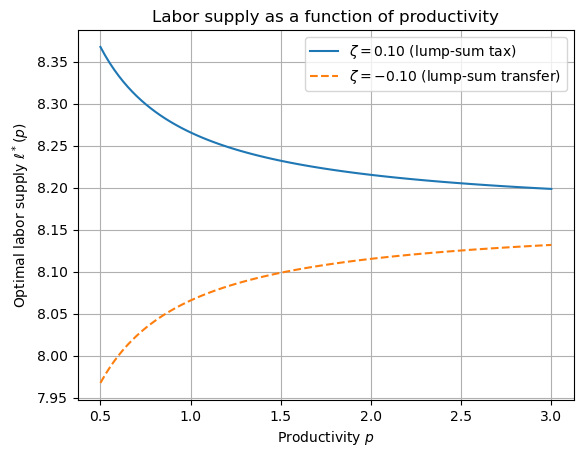

p = 0.50:  ell*(zeta=0.10) = 8.367,  ell*(zeta=-0.10) = 7.967
p = 1.13:  ell*(zeta=0.10) = 8.254,  ell*(zeta=-0.10) = 8.077
p = 1.76:  ell*(zeta=0.10) = 8.222,  ell*(zeta=-0.10) = 8.108
p = 2.39:  ell*(zeta=0.10) = 8.207,  ell*(zeta=-0.10) = 8.123
p = 3.00:  ell*(zeta=0.10) = 8.198,  ell*(zeta=-0.10) = 8.132


In [6]:
# Labor supply as a function of productivity 
# 1. Create worker with baseline parameters
worker = WorkerClass()

# productivity grid 
ps = np.linspace(0.5, 3.0, 100)

ell_star_baseline = np.zeros_like(ps)
ell_star_transfer = np.zeros_like(ps)

# 2. Baseline case: zeta = 0.1 (lump-sum tax)
worker.par.zeta = 0.10
for i, p in enumerate(ps):
    opt = worker.optimal_choice(p)
    ell_star_baseline[i] = opt.ell

# 3. Transfer case: zeta = -0.1 (lump-sum transfer)
worker.par.zeta = -0.10
for i, p in enumerate(ps):
    opt = worker.optimal_choice(p)
    ell_star_transfer[i] = opt.ell

# 4. Plot labor supply functions
plt.figure()
plt.plot(ps, ell_star_baseline, label=r"$\zeta = 0.10$ (lump-sum tax)")
plt.plot(ps, ell_star_transfer, label=r"$\zeta = -0.10$ (lump-sum transfer)", linestyle="--")
plt.xlabel("Productivity $p$")
plt.ylabel("Optimal labor supply $\\ell^*(p)$")
plt.title("Labor supply as a function of productivity")
plt.legend()
plt.grid(True)
plt.show()

# (optional) check a few values
for idx in [0, 25, 50, 75, 99]:
    print(f"p = {ps[idx]:.2f}:  ell*(zeta=0.10) = {ell_star_baseline[idx]:.3f},  ell*(zeta=-0.10) = {ell_star_transfer[idx]:.3f}")


#### Interpretation of Section 1.2 — Labor Supply as a Function of Productivity

In this section, we compute the optimal labor supply function $ \ell^*(p) $ for workers with productivities ranging from $ p \in [0.5, 3.0] $. Using the same utility maximization problem as in Section 1.1, we first calculate $ \ell^*(p) $ under the baseline tax system with a lump-sum tax of $ \zeta = 0.10 $. The resulting labor supply curve is slightly downward-sloping: as productivity increases, workers supply marginally fewer hours. This happens because higher productivity increases income per hour, which lowers the marginal utility gain from additional labor, leading workers to reduce labor supply.

Next, we repeat the computation after switching to a lump-sum **transfer**, $ \zeta = -0.10 $. In this case, the entire labor supply curve shifts downward. Receiving a transfer increases non-labor income, generating a pure income effect that reduces labor supply for all productivity levels. The curve becomes slightly upward-sloping because the transfer becomes relatively less important as productivity rises, causing labor supply to increase gradually again.

Overall, these results show how optimal labor supply reacts to differences in productivity and how lump-sum taxes or transfers shift incentives. A positive lump-sum tax induces slightly more labor supply, while a lump-sum transfer reduces labor supply uniformly. This directly answers the project’s questions about how $ \ell^*(p) $ behaves under different values of $ \zeta $ and different productivity levels.


## 2. Public Goods
### 2.1 Tax Revenue and Social Welfare Function

In [7]:
gov = GovernmentClass()
gov.par.tau = 0.50
gov.par.zeta = 0.10  # baseline in the project

gov.draw_productivities()
gov.solve_workers()
T_val = gov.tax_revenue()
SWF_val = gov.SWF()

print("Tax revenue T(τ=0.5, ζ=0.1) =", T_val)
print("Social Welfare SWF(τ=0.5, ζ=0.1) =", SWF_val)


Tax revenue T(τ=0.5, ζ=0.1) = 417.911778452465
Social Welfare SWF(τ=0.5, ζ=0.1) = 174.04529656948384


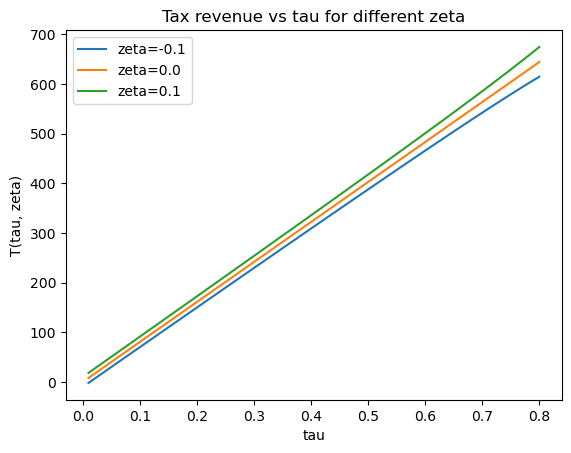

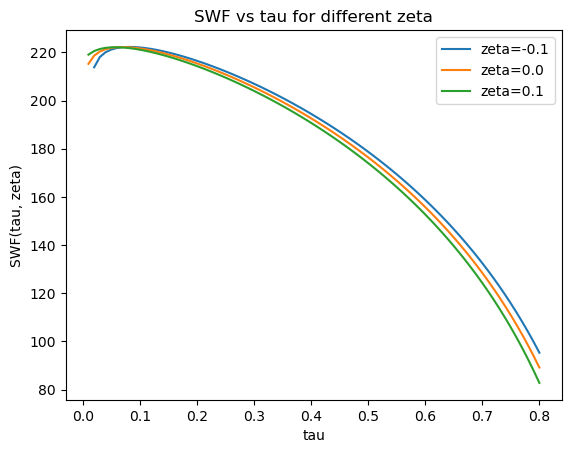

In [8]:
# 1) set up government + draw productivities 
gov = GovernmentClass()
gov.draw_productivities()

# 2) grids
zeta_list = [-0.1, 0.0, 0.1]
tau_grid = np.linspace(0.01, 0.80, 80)

# 3) containers
T_dict = {}
SWF_dict = {}

# 4) loop over zeta and tau
for zeta in zeta_list:
    gov.par.zeta = zeta

    T_vals = np.empty_like(tau_grid)
    SWF_vals = np.empty_like(tau_grid)

    for j, tau in enumerate(tau_grid):
        gov.par.tau = tau

        gov.solve_workers()          # step 2: labor supply for each worker
        T = gov.tax_revenue()        # step 3: sum taxes (minus transfers)
        SWF = gov.SWF()              # step 4: welfare (returns nan if T<0 in your code)

        T_vals[j] = T
        SWF_vals[j] = SWF

    T_dict[zeta] = T_vals
    SWF_dict[zeta] = SWF_vals

# 5) plot T(tau,zeta)
plt.figure()
for zeta in zeta_list:
    plt.plot(tau_grid, T_dict[zeta], label=f"zeta={zeta}")
plt.xlabel("tau")
plt.ylabel("T(tau, zeta)")
plt.title("Tax revenue vs tau for different zeta")
plt.legend()
plt.show()

# 6) plot SWF(tau,zeta)
plt.figure()
for zeta in zeta_list:
    plt.plot(tau_grid, SWF_dict[zeta], label=f"zeta={zeta}")
plt.xlabel("tau")
plt.ylabel("SWF(tau, zeta)")
plt.title("SWF vs tau for different zeta")
plt.legend()
plt.show()

#### Interpretation of Section 2.1

1) **Benchmark simulation ($\tau=0.5,\ \zeta=0.1$)**  
For the benchmark tax system with $ \tau = 0.5 $ and $ \zeta = 0.1 $, we begin by drawing productivity levels for $ N = 100 $ workers using the lognormal distribution specified in the project. Using these productivities, we solve each worker’s utility-maximization problem to obtain individual labor supply, consumption, and utility. Based on the simulated population, total tax revenue is $ T = 417.91 $, reflecting both the lump-sum tax paid by all workers and the proportional tax collected on labor income. The resulting social welfare is $ SWF = 174.05 $, combining the public good term with the sum of workers’ utilities. Overall, this confirms that under the benchmark parameters, the government raises substantial revenue and social welfare is well-defined given the population’s optimal choices.

2) **Tax revenue and welfare as $\tau$ varies (for different $\zeta$)**  
We then vary the tax rate over $ \tau \in [0.01, 0.80] $ and plot $ T(\tau,\zeta) $ and $ SWF(\tau,\zeta) $ for $ \zeta \in \{-0.1, 0, 0.1\} $. In the simulations, tax revenue increases with $\tau$ across the entire range, suggesting that (within this parameterization) the reduction in labor supply from higher taxes is not strong enough to generate a Laffer-curve peak before $\tau=0.8$. Across all $\tau$, higher $\zeta$ shifts the tax revenue curve upward because the lump-sum component directly adds to total revenue.

3) **Shape of $SWF(\tau,\zeta)$ and the policy trade-off**  
In contrast, the welfare curves are hump-shaped: welfare increases at low $\tau$ but eventually declines as the distortionary effect of taxation on labor supply and consumption dominates the benefit from higher public spending. Comparing across $\zeta$, welfare tends to be lower when $\zeta$ is higher, because a larger lump-sum tax reduces private consumption for all workers. Taken together, these results illustrate the core policy trade-off in the model: raising $\tau$ (and/or $\zeta$) increases government resources, but beyond a point it lowers overall welfare due to stronger behavioral distortions and reduced private consumption.


### 2.2 Optimal Tax System

In [9]:
import numpy as np
from scipy.optimize import minimize
from Government import GovernmentClass

# set up government and FIX ONE draw of productivities
gov = GovernmentClass()

# safety (in case b is not defined elsewhere)
if not hasattr(gov.par, "b"):
    gov.par.b = 0.0

gov.draw_productivities()
ps_fixed = gov.par.ps.copy()   # keep fixed across all evaluations

# objective: maximize SWF(tau,zeta)  <=> minimize -SWF(tau,zeta)
def neg_swf(x):
    tau, zeta = x

    # keep the same simulated population
    gov.par.ps = ps_fixed
    gov.sol.ps = ps_fixed

    gov.par.tau = float(tau)
    gov.par.zeta = float(zeta)

    gov.solve_workers()
    swf = gov.SWF()

    # penalize infeasible cases (e.g., negative revenue -> SWF = nan)
    if not np.isfinite(swf):
        return 1e12

    return -swf

# bounds (project says tau in [0,1); zeta unbounded in theory -> use practical bounds)
bounds = [(0.0, 0.95), (-2.0, 2.0)]
x0 = np.array([0.5, 0.1])  # reasonable start

res = minimize(neg_swf, x0=x0, method="L-BFGS-B", bounds=bounds)

tau_star, zeta_star = res.x
SWF_star = -res.fun

print(f"tau*  = {tau_star:.6f}")
print(f"zeta* = {zeta_star:.6f}")
print(f"SWF*  = {SWF_star:.6f}")
print("converged:", res.success, "|", res.message)


tau*  = 0.137108
zeta* = -0.526001
SWF*  = 222.384069
converged: True | CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [10]:
import numpy as np
from scipy.optimize import minimize

# reuse: gov, ps_fixed, neg_swf, bounds from 2.2.1

starts = [
    [0.1, 0.0],
    [0.8, -0.2],
    [0.3, 0.2],
    [0.5, 0.1],
]

sols = []
for x0 in starts:
    res0 = minimize(neg_swf, x0=np.array(x0), method="L-BFGS-B", bounds=bounds)
    tau0, zeta0 = res0.x
    swf0 = -res0.fun
    sols.append((x0, tau0, zeta0, swf0, res0.success))
    print(f"start={x0} -> tau={tau0:.6f}, zeta={zeta0:.6f}, SWF={swf0:.6f}, ok={res0.success}")

# quick consistency check (how different are the solutions?)
taus  = np.array([s[1] for s in sols])
zetas = np.array([s[2] for s in sols])
swfs  = np.array([s[3] for s in sols])

print("\nmax |tau - mean|  =", np.max(np.abs(taus - np.mean(taus))))
print("max |zeta - mean| =", np.max(np.abs(zetas - np.mean(zetas))))
print("max |SWF - mean|  =", np.max(np.abs(swfs - np.mean(swfs))))


start=[0.1, 0.0] -> tau=0.100000, zeta=-0.000000, SWF=221.654500, ok=True
start=[0.8, -0.2] -> tau=0.136808, zeta=-0.523734, SWF=222.384073, ok=True
start=[0.3, 0.2] -> tau=0.136742, zeta=-0.523226, SWF=222.384073, ok=True
start=[0.5, 0.1] -> tau=0.137108, zeta=-0.526001, SWF=222.384069, ok=True

max |tau - mean|  = 0.02766432885028594
max |zeta - mean| = 0.39324026731683875
max |SWF - mean|  = 0.5471785344039688


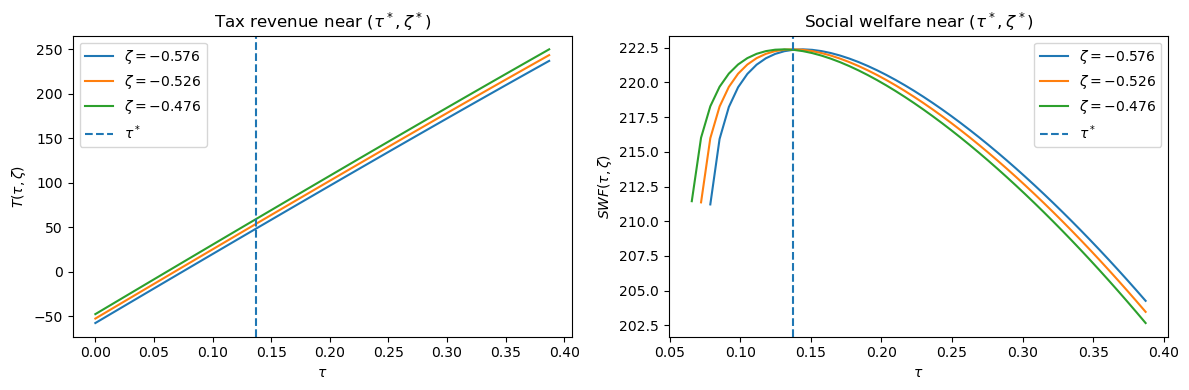

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# reuse: gov, ps_fixed, tau_star, zeta_star from 2.2.1

# tau grid close to tau*
tau_grid = np.linspace(max(0.0, tau_star - 0.25), min(0.95, tau_star + 0.25), 60)

# multiple zeta lines close to zeta*
zeta_list = [zeta_star - 0.05, zeta_star, zeta_star + 0.05]

T_dict = {}
SWF_dict = {}

for zeta in zeta_list:
    T_vals = np.empty_like(tau_grid)
    SWF_vals = np.empty_like(tau_grid)

    for j, tau in enumerate(tau_grid):
        gov.par.ps = ps_fixed
        gov.sol.ps = ps_fixed

        gov.par.tau = float(tau)
        gov.par.zeta = float(zeta)

        gov.solve_workers()
        T_vals[j] = gov.tax_revenue()
        SWF_vals[j] = gov.SWF()

    T_dict[zeta] = T_vals
    SWF_dict[zeta] = SWF_vals

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Tax revenue
for zeta in zeta_list:
    ax[0].plot(tau_grid, T_dict[zeta], label=fr"$\zeta={zeta:.3f}$")
ax[0].axvline(tau_star, linestyle="--", label=r"$\tau^*$")
ax[0].set_xlabel(r"$\tau$")
ax[0].set_ylabel(r"$T(\tau,\zeta)$")
ax[0].set_title(r"Tax revenue near $(\tau^*,\zeta^*)$")
ax[0].legend()

# Social welfare
for zeta in zeta_list:
    ax[1].plot(tau_grid, SWF_dict[zeta], label=fr"$\zeta={zeta:.3f}$")
ax[1].axvline(tau_star, linestyle="--", label=r"$\tau^*$")
ax[1].set_xlabel(r"$\tau$")
ax[1].set_ylabel(r"$SWF(\tau,\zeta)$")
ax[1].set_title(r"Social welfare near $(\tau^*,\zeta^*)$")
ax[1].legend()

plt.tight_layout()
plt.show()


In [12]:
def lorenz_curve(values):
    """
    Given a 1D array of non-negative values (e.g. consumption),
    return population shares and cumulative shares of the variable.
    """
    x = np.sort(values)
    n = len(x)
    cum_vals = np.cumsum(x)
    total = cum_vals[-1]
    
    # population shares (from 0 to 1)
    pop_share = np.linspace(0.0, 1.0, n+1)
    pop_share[0] = 0.0
    
    # value shares (from 0 to 1)
    val_share = np.concatenate(([0.0], cum_vals / total))
    
    return pop_share, val_share


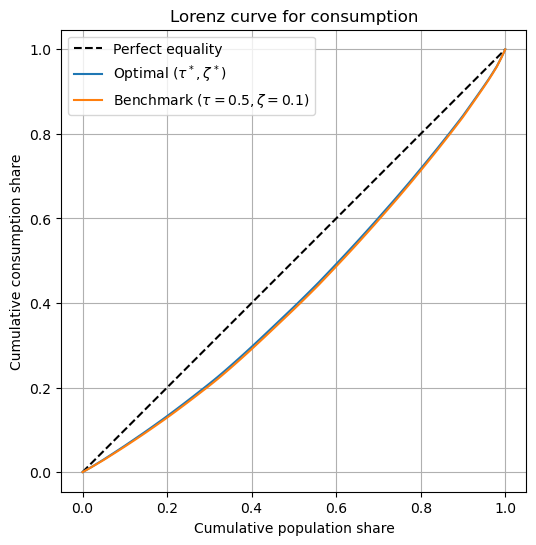

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# reuse: lorenz_curve (your existing function), gov, ps_fixed, tau_star, zeta_star

# --- optimal taxes: solve ONCE at (tau*, zeta*) ---
gov.par.ps = ps_fixed
gov.sol.ps = ps_fixed
gov.par.tau = float(tau_star)
gov.par.zeta = float(zeta_star)
gov.solve_workers()
cs_opt = gov.sol.cs.copy()
pop_opt, lorenz_opt = lorenz_curve(cs_opt)

# --- benchmark: same population, just change taxes and solve again ---
gov.par.tau = 0.5
gov.par.zeta = 0.1
gov.solve_workers()
cs_bench = gov.sol.cs.copy()
pop_bench, lorenz_bench = lorenz_curve(cs_bench)

# --- plot ---
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect equality")

plt.plot(pop_opt, lorenz_opt, label=r"Optimal $(\tau^*,\zeta^*)$")
plt.plot(pop_bench, lorenz_bench, label=r"Benchmark $(\tau=0.5,\zeta=0.1)$")

plt.xlabel("Cumulative population share")
plt.ylabel("Cumulative consumption share")
plt.title("Lorenz curve for consumption")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()


#### Interpretation of Section 2.2

1) **Finding the optimal tax system (optimizer vs grid search)**  
To identify the welfare-maximizing tax structure, we maximize the social welfare function $SWF(\tau,\zeta)$ over combinations of the proportional tax rate $\tau$ and the lump-sum component $\zeta$. Following the TA’s suggestion, we replace the grid search with a SciPy optimizer, which searches the parameter space more efficiently and can locate optima between grid points. In our simulations, the optimizer converges to an optimum around
$ \tau^* \approx 0.137, \qquad \zeta^* \approx -0.526, $
with welfare approximately $SWF^* \approx 222.384$. This is substantially higher than the benchmark system in Section 2.1 (e.g., $SWF(0.5,0.1)$), indicating that the benchmark tax rate is too distortionary in this model.

2) **Role of bounds and corner solutions for $\zeta$**  
A key numerical feature is that the optimal $\zeta$ tends to be negative, and in earlier runs it was pinned at the imposed lower bound. After widening the bounds, the solution moves slightly below $-0.5$ (e.g., $\zeta^* \approx -0.526$), suggesting that the welfare-maximizing policy favors net transfers rather than positive lump-sum taxation in this calibration. The fact that the solution can be close to a boundary highlights that bounds matter for numerical optimization and should be chosen wide enough to avoid artificially truncating the optimum.

3) **Robustness to starting values**  
We also test robustness by running the optimizer from several starting points $(\tau_0,\zeta_0)$. Most initial values converge to essentially the same solution with very similar welfare, indicating the optimum is stable within the relevant region. However, one starting point can converge to a clearly worse solution (lower $SWF$), which suggests that the problem may contain flat regions or local optima where the gradient-based routine stops early. For interpretation, the main takeaway is that the high-welfare solution around $(\tau^*,\zeta^*)$ is reproducible across reasonable starting values, but it is still important to verify convergence by checking that different initial guesses reach the same high-welfare basin.

4) **Interpreting the plots and distributional effects (multiple $\zeta$ lines + Lorenz curve)**  
To understand the local behavior near the optimum, we plot $T(\tau,\zeta)$ and $SWF(\tau,\zeta)$ for $\tau$ close to $\tau^*$ and for multiple nearby values of $\zeta$ (as requested by the TA). The tax revenue curve $T(\tau,\zeta)$ increases with $\tau$ over the plotted region, while the welfare curve $SWF(\tau,\zeta)$ is hump-shaped: welfare initially rises as tax revenue finances the public good, but declines once the distortion to labor supply dominates. The peak occurs close to $\tau^*$, supporting that the optimal $\tau$ is an interior solution. Finally, comparing Lorenz curves for consumption under $(\tau^*,\zeta^*)$ versus the benchmark $(\tau,\zeta)=(0.5,0.1)$ shows only a small change in inequality in this simulation, meaning the welfare gain is driven mainly by efficiency (lower distortions) rather than large distributional changes.


## 3. Top Tax
### 3.1 Labor Supply

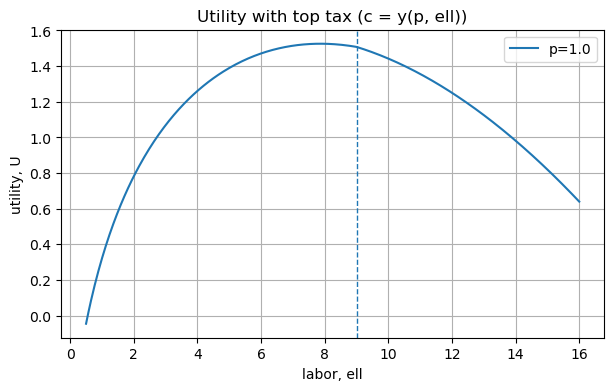

Using tau=tau*=0.137108, zeta=zeta*=-0.526001, kappa=9.0, omega=0.2


In [14]:
# 3.1.1

import numpy as np
import matplotlib.pyplot as plt
from Worker import WorkerClass

# parameters
tau_star  = 0.137108   
zeta_star = -0.526001  

kappa = 9.0
omega = 0.2

# productivities to plot
ps = [1.0]  

# setup worker with top tax
worker = WorkerClass()
worker.par.tau   = tau_star
worker.par.zeta  = zeta_star
worker.par.kappa = kappa
worker.par.omega = omega

# grid for labor
ell_grid = np.linspace(0.5, worker.par.ell_max, 400)

# plot
plt.figure(figsize=(7,4))

for p in ps:
    c_vals = np.array([worker.post_tax_income(p, ell) for ell in ell_grid])
    U_vals = np.array([worker.utility(c, ell) for c, ell in zip(c_vals, ell_grid)])
    plt.plot(ell_grid, U_vals, label=f"p={p}")

# kink location (in labor units): ell = kappa/(w*p)
for p in ps:
    ell_kink = worker.par.kappa / (worker.par.w * p)
    plt.axvline(ell_kink, linestyle="--", linewidth=1)

plt.title("Utility with top tax (c = y(p, ell))")
plt.xlabel("labor, ell")
plt.ylabel("utility, U")
plt.legend()
plt.grid(True)
plt.show()

print(f"Using tau=tau*={tau_star:.6f}, zeta=zeta*={zeta_star:.6f}, kappa={kappa}, omega={omega}")


#### Interpretation (3.1.1 — Utility plot):
The utility function $U(\ell)$ is single-peaked on $\ell \in [0.5,\bar{\ell}]$, so there is a well-defined optimal labor supply. The dashed line marks the kink at $\ell_k=\kappa/(wp)$ where the top tax begins to apply, and the peak occurring left of $\ell_k$ suggests the worker prefers to stay below the top-tax threshold.


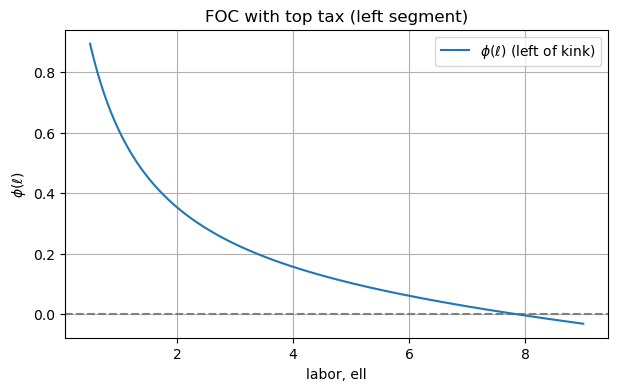

p=1.0, kink ell = kappa/(w*p) = 9.0000
Using tau=tau*=0.137108, zeta=zeta*=-0.526001, kappa=9.0, omega=0.2


In [15]:
# 3.1.2

import numpy as np
import matplotlib.pyplot as plt
from Worker import WorkerClass

# parameters 
tau_star  = 0.137108   
zeta_star = -0.526001  

kappa = 9.0
omega = 0.2

p = 1.0  

worker = WorkerClass()
worker.par.tau   = tau_star
worker.par.zeta  = zeta_star
worker.par.kappa = kappa
worker.par.omega = omega

# kink at ell = kappa/(w*p)
ell_kink = worker.par.kappa / (worker.par.w * p)

# grid: from 0.5 to kink (cap at ell_max just in case)
ell_high = min(ell_kink, worker.par.ell_max)
ell_grid = np.linspace(0.5, ell_high, 400)

# FOC values (with c = y(p, ell) inside worker.FOC via post_tax_income)
phi_vals = np.array([worker.FOC(p, ell) for ell in ell_grid])

plt.figure(figsize=(7,4))
plt.axhline(0, linestyle="--", color="grey")
plt.plot(ell_grid, phi_vals, label=r"$\phi(\ell)$ (left of kink)")
plt.title("FOC with top tax (left segment)")
plt.xlabel("labor, ell")
plt.ylabel(r"$\phi(\ell)$")
plt.legend()
plt.grid(True)
plt.show()

print(f"p={p}, kink ell = kappa/(w*p) = {ell_kink:.4f}")
print(f"Using tau=tau*={tau_star:.6f}, zeta=zeta*={zeta_star:.6f}, kappa={kappa}, omega={omega}")


#### Interpretation (3.1.2 — FOC plot, left of kink): 
On $\ell \in [0.5,\ell_k]$, the FOC $\phi(\ell)$ crosses zero once, indicating an interior solution exists on the left segment. This zero crossing is the candidate optimum as long as it yields higher utility than the boundary points.


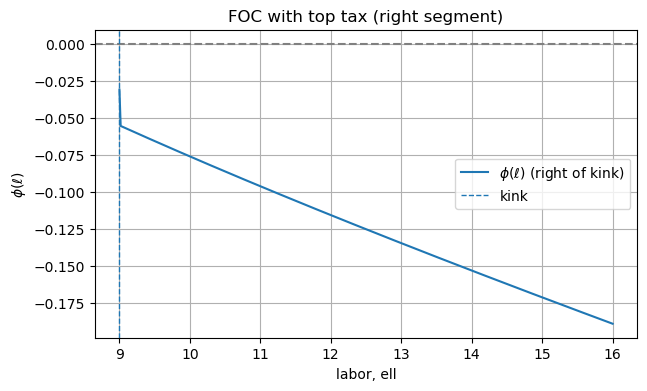

p=1.0, kink ell = kappa/(w*p) = 9.0000
Using tau=tau*=0.137108, zeta=zeta*=-0.526001, kappa=9.0, omega=0.2


In [16]:
# 3.1.3

import numpy as np
import matplotlib.pyplot as plt
from Worker import WorkerClass

# parameters
tau_star  = 0.137108   
zeta_star = -0.526001  

kappa = 9.0
omega = 0.2

p = 1.0 

worker = WorkerClass()
worker.par.tau   = tau_star
worker.par.zeta  = zeta_star
worker.par.kappa = kappa
worker.par.omega = omega

# kink at ell = kappa/(w*p)
ell_kink = worker.par.kappa / (worker.par.w * p)

# grid: from kink to ell_max (ensure lower bound is not above ell_max)
ell_low = min(ell_kink, worker.par.ell_max)
ell_grid = np.linspace(ell_low, worker.par.ell_max, 400)

phi_vals = np.array([worker.FOC(p, ell) for ell in ell_grid])

plt.figure(figsize=(7,4))
plt.axhline(0, linestyle="--", color="grey")
plt.plot(ell_grid, phi_vals, label=r"$\phi(\ell)$ (right of kink)")
plt.axvline(ell_kink, linestyle="--", linewidth=1, label="kink")
plt.title("FOC with top tax (right segment)")
plt.xlabel("labor, ell")
plt.ylabel(r"$\phi(\ell)$")
plt.legend()
plt.grid(True)
plt.show()

print(f"p={p}, kink ell = kappa/(w*p) = {ell_kink:.4f}")
print(f"Using tau=tau*={tau_star:.6f}, zeta=zeta*={zeta_star:.6f}, kappa={kappa}, omega={omega}")


#### Interpretation (3.1.3 — FOC plot, right of kink):
On $\ell \in [\ell_k,\bar{\ell}]$, the FOC stays below zero, so there is no interior root on the right segment. This implies the optimum cannot lie strictly above the kink, consistent with the utility peak occurring before $\ell_k$.


In [17]:
# 3.1.4

import numpy as np
import time
from scipy.optimize import minimize_scalar
from Worker import WorkerClass

# parameters
tau_star  = 0.137108
zeta_star = -0.526001

kappa = 9.0
omega = 0.2

p = 1.0  

worker = WorkerClass()
worker.par.tau   = tau_star
worker.par.zeta  = zeta_star
worker.par.kappa = kappa
worker.par.omega = omega

# objective: maximize utility => minimize negative utility
def neg_utility(ell):
    c = worker.post_tax_income(p, ell)
    return -worker.utility(c, ell)

# bounds for ell
ell_low = 0.5
ell_high = worker.par.ell_max

t0 = time.perf_counter()
res = minimize_scalar(neg_utility, bounds=(ell_low, ell_high), method="bounded")
t_opt = time.perf_counter() - t0

ell_star_opt = res.x
U_star = -res.fun

print(f"p={p}")
print(f"ell* (optimizer) = {ell_star_opt:.6f}")
print(f"U(ell*)          = {U_star:.6f}")
print(f"time optimizer   = {t_opt*1000:.3f} ms")
print("converged:", res.success, "|", res.message)


p=1.0
ell* (optimizer) = 7.865863
U(ell*)          = 1.525669
time optimizer   = 0.277 ms
converged: True | Solution found.


#### Interpretation (3.1.4 — Numerical optimizer):
The numerical optimizer finds the optimal labor supply $\ell^*(p)$ by directly maximizing $U(\ell)$ over $[0.5,\bar{\ell}]$. The resulting $\ell^*$ should align with the peak of the utility plot and provides a benchmark value for comparing with the FOC-based method.


In [18]:
# 3.1.5

import numpy as np
import time
from scipy.optimize import brentq
from Worker import WorkerClass

# parameters 
tau_star  = 0.137108
zeta_star = -0.526001

kappa = 9.0
omega = 0.2

p = 1.0 

worker = WorkerClass()
worker.par.tau   = tau_star
worker.par.zeta  = zeta_star
worker.par.kappa = kappa
worker.par.omega = omega

ell_low = 0.5
ell_max = worker.par.ell_max

# kink
ell_kink = worker.par.kappa / (worker.par.w * p)
ell_kink = min(ell_kink, ell_max)  # safety

# FOC on each segment:
# phi(ell) = (marginal net wage)/c(ell) - nu * ell^epsilon
# where marginal net wage differs across the kink
def phi_left(ell):
    c = worker.post_tax_income(p, ell)
    if c <= 0:
        return np.nan
    mnet = (1 - worker.par.tau) * worker.par.w * p
    return mnet / c - worker.par.nu * ell**worker.par.epsilon

def phi_right(ell):
    c = worker.post_tax_income(p, ell)
    if c <= 0:
        return np.nan
    mnet = (1 - worker.par.tau - worker.par.omega) * worker.par.w * p
    return mnet / c - worker.par.nu * ell**worker.par.epsilon

# helper: safe root finding if sign change
def try_root(phi_func, a, b):
    fa, fb = phi_func(a), phi_func(b)
    if (not np.isfinite(fa)) or (not np.isfinite(fb)):
        return np.nan
    if fa == 0:
        return a
    if fb == 0:
        return b
    if fa * fb > 0:
        return np.nan  # no sign change => no brentq root
    return brentq(phi_func, a, b)

# time the whole FOC procedure
t0 = time.perf_counter()

# 1) root on left segment [ell_low, ell_kink]
root_left = try_root(phi_left, ell_low, ell_kink)

# 2) root on right segment [ell_kink, ell_max]
# (only meaningful if ell_kink < ell_max)
root_right = np.nan
if ell_kink < ell_max:
    root_right = try_root(phi_right, ell_kink, ell_max)

# 3) collect candidate points: boundaries + kink + any roots
candidates = [ell_low, ell_max, ell_kink]
if np.isfinite(root_left):
    candidates.append(root_left)
if np.isfinite(root_right):
    candidates.append(root_right)

# 4) evaluate utility and pick best feasible candidate
def util_at(ell):
    c = worker.post_tax_income(p, ell)
    if c <= 0:
        return -np.inf
    return worker.utility(c, ell)

cand_utils = [(ell, util_at(ell)) for ell in candidates]
ell_star_foc, U_star_foc = max(cand_utils, key=lambda x: x[1])

t_root = time.perf_counter() - t0

print(f"p={p}")
print(f"kink ell_k = {ell_kink:.6f}")
print(f"root left  = {root_left}")
print(f"root right = {root_right}")
print(f"ell* (FOC method) = {ell_star_foc:.6f}")
print(f"U(ell*)           = {U_star_foc:.6f}")
print(f"time FOC method   = {t_root*1000:.3f} ms")

print("\nCandidates (ell, U):")
for ell, U in cand_utils:
    print(f"  ell={ell:.6f}, U={U:.6f}")


p=1.0
kink ell_k = 9.000000
root left  = 7.865862975167634
root right = nan
ell* (FOC method) = 7.865863
U(ell*)           = 1.525669
time FOC method   = 0.462 ms

Candidates (ell, U):
  ell=0.500000, U=-0.045360
  ell=16.000000, U=0.639726
  ell=9.000000, U=1.507795
  ell=7.865863, U=1.525669


#### Interpretation (3.1.5 — Four-step FOC method): 
The four-step approach accounts for the kink by searching for FOC roots separately on each segment and then comparing candidate points (left-root, right-root if any, the kink, and the boundaries). The selected $\ell^*$ is the candidate that yields the highest utility, which ensures correctness even when the FOC has no solution on part of the domain.


In [19]:
#3.1.6

import numpy as np

# Compare levels
diff = abs(ell_star_opt - ell_star_foc)

print(f"p={p}")
print(f"ell* optimizer  = {ell_star_opt:.6f}")
print(f"ell* FOC method = {ell_star_foc:.6f}")
print(f"|difference|    = {diff:.6e}")

# Compare speed
if np.isnan(t_root):
    faster = "optimizer (FOC failed)"
else:
    faster = "optimizer" if t_opt < t_root else "FOC method"

print(f"time optimizer  = {t_opt*1000:.3f} ms")
print(f"time FOC method = {t_root*1000:.3f} ms")
print("fastest method  =", faster)


p=1.0
ell* optimizer  = 7.865863
ell* FOC method = 7.865863
|difference|    = 1.438133e-07
time optimizer  = 0.277 ms
time FOC method = 0.462 ms
fastest method  = optimizer


#### Interpretation (3.1.6 — Compare methods and timing): 
The optimizer and the FOC-based method produce essentially identical $\ell^*$, confirming that both approaches identify the same optimum. Comparing runtimes shows which method is faster in this kinked setting, where the FOC approach may require additional checks across segments and candidate points.

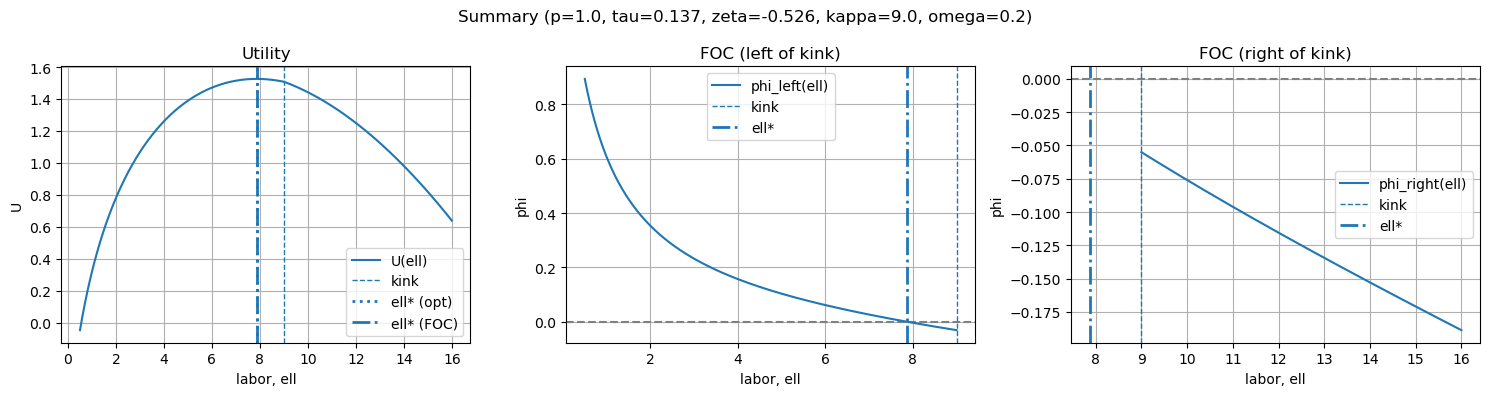

In [20]:
# 3.1.7

import numpy as np
import matplotlib.pyplot as plt
from Worker import WorkerClass

# parameters 
tau_star  = 0.137108
zeta_star = -0.526001
kappa = 9.0
omega = 0.2
p = 1.0

worker = WorkerClass()
worker.par.tau   = tau_star
worker.par.zeta  = zeta_star
worker.par.kappa = kappa
worker.par.omega = omega

ell_low = 0.5
ell_max = worker.par.ell_max
ell_kink = min(worker.par.kappa / (worker.par.w * p), ell_max)

# grids
ell_grid_all = np.linspace(ell_low, ell_max, 500)

ell_grid_left = np.linspace(ell_low, ell_kink, 300)
ell_grid_right = np.linspace(ell_kink, ell_max, 300)

# Utility
c_all = np.array([worker.post_tax_income(p, ell) for ell in ell_grid_all])
U_all = np.array([worker.utility(c, ell) if c > 0 else np.nan for c, ell in zip(c_all, ell_grid_all)])

# FOC left/right (same definitions as Step 5)
def phi_left(ell):
    c = worker.post_tax_income(p, ell)
    if c <= 0:
        return np.nan
    mnet = (1 - worker.par.tau) * worker.par.w * p
    return mnet / c - worker.par.nu * ell**worker.par.epsilon

def phi_right(ell):
    c = worker.post_tax_income(p, ell)
    if c <= 0:
        return np.nan
    mnet = (1 - worker.par.tau - worker.par.omega) * worker.par.w * p
    return mnet / c - worker.par.nu * ell**worker.par.epsilon

phi_L = np.array([phi_left(ell) for ell in ell_grid_left])
phi_R = np.array([phi_right(ell) for ell in ell_grid_right])

# --- make the combined figure ---
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# (1) Utility
ax[0].plot(ell_grid_all, U_all, label="U(ell)")
ax[0].axvline(ell_kink, linestyle="--", linewidth=1, label="kink")
ax[0].axvline(ell_star_opt, linestyle=":", linewidth=2, label="ell* (opt)")
ax[0].axvline(ell_star_foc, linestyle="-.", linewidth=2, label="ell* (FOC)")
ax[0].set_title("Utility")
ax[0].set_xlabel("labor, ell")
ax[0].set_ylabel("U")
ax[0].legend()
ax[0].grid(True)

# (2) FOC left
ax[1].axhline(0, linestyle="--", color="grey")
ax[1].plot(ell_grid_left, phi_L, label="phi_left(ell)")
ax[1].axvline(ell_kink, linestyle="--", linewidth=1, label="kink")
ax[1].axvline(ell_star_foc, linestyle="-.", linewidth=2, label="ell*")
ax[1].set_title("FOC (left of kink)")
ax[1].set_xlabel("labor, ell")
ax[1].set_ylabel("phi")
ax[1].legend()
ax[1].grid(True)

# (3) FOC right
ax[2].axhline(0, linestyle="--", color="grey")
ax[2].plot(ell_grid_right, phi_R, label="phi_right(ell)")
ax[2].axvline(ell_kink, linestyle="--", linewidth=1, label="kink")
ax[2].axvline(ell_star_foc, linestyle="-.", linewidth=2, label="ell*")
ax[2].set_title("FOC (right of kink)")
ax[2].set_xlabel("labor, ell")
ax[2].set_ylabel("phi")
ax[2].legend()
ax[2].grid(True)

fig.suptitle(f"Summary (p={p}, tau={tau_star:.3f}, zeta={zeta_star:.3f}, kappa={kappa}, omega={omega})")
plt.tight_layout()
plt.show()


#### Interpretation (3.1.7 — Combined summary figure):  
The combined figure summarizes the full logic: the utility peak matches the zero crossing of $\phi(\ell)$ on the left segment, while the right segment has no root, ruling out an optimum above the kink. Marking $\ell^*$ and $\ell_k$ makes it clear how the top tax threshold shapes the worker’s labor choice.



=== p=1.175 ===
kink ell_k = 7.659574
ell* optimizer  = 7.659572 (U=1.675277, time=0.405 ms)
ell* FOC method = 7.659574 (U=1.675277, time=0.031 ms)
|difference|    = 2.547e-06
fastest method  = FOC method


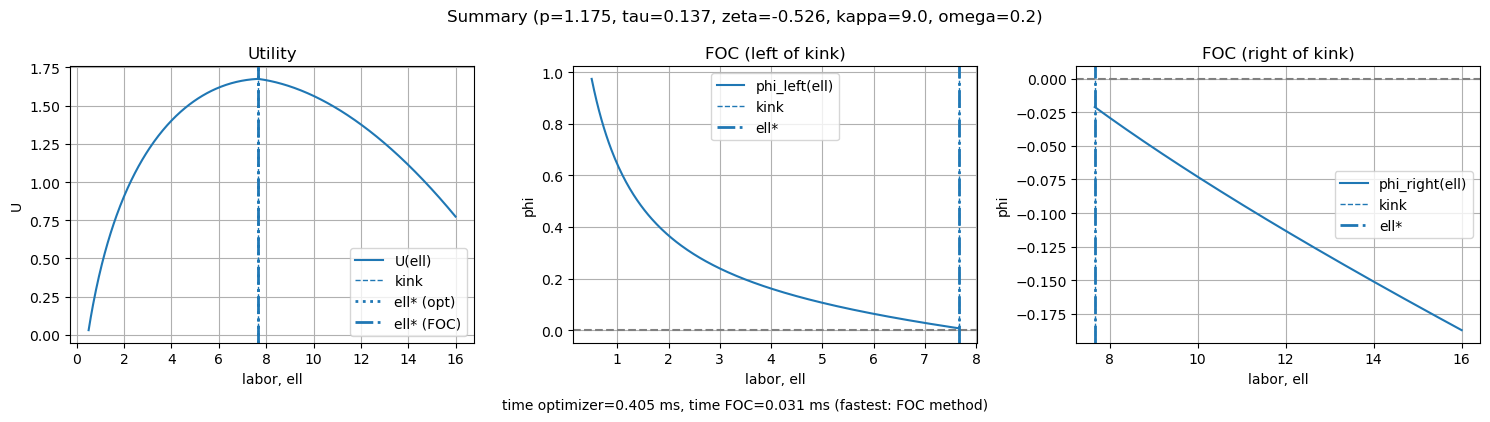


=== p=1.5 ===
kink ell_k = 6.000000
ell* optimizer  = 7.078690 (U=1.861129, time=0.182 ms)
ell* FOC method = 7.078691 (U=1.861129, time=0.061 ms)
|difference|    = 8.890e-07
fastest method  = FOC method


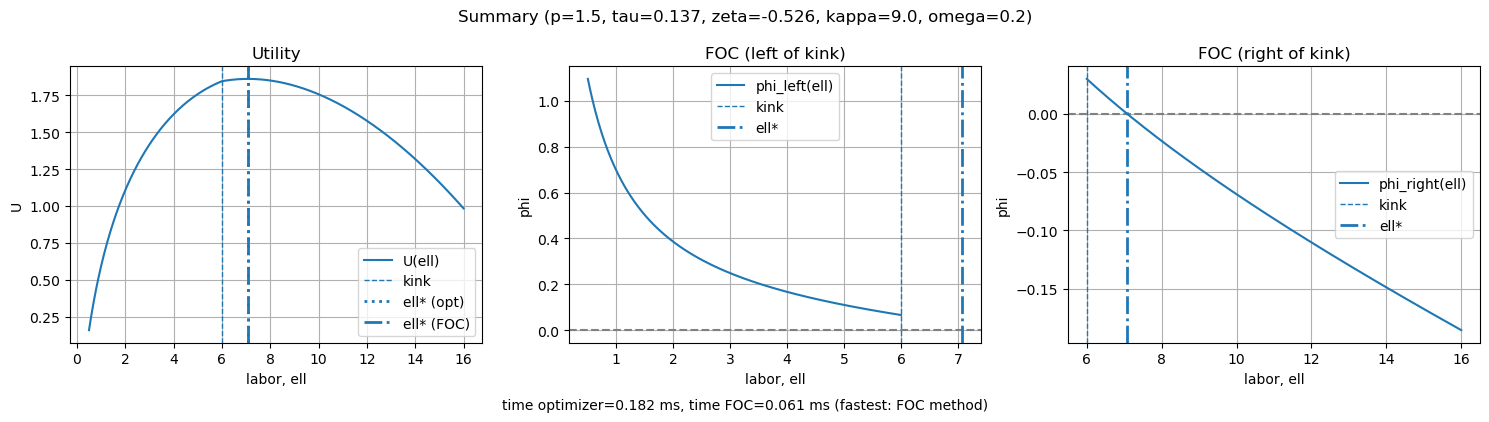

In [21]:
# 3.1.8 repeat for different p values
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar, brentq
from Worker import WorkerClass

# parameters 
tau_star  = 0.137108
zeta_star = -0.526001
kappa = 9.0
omega = 0.2

p_list = [1.175, 1.5]

def analyze_p(p, make_plot=True):
    worker = WorkerClass()
    worker.par.tau   = tau_star
    worker.par.zeta  = zeta_star
    worker.par.kappa = kappa
    worker.par.omega = omega

    ell_low = 0.5
    ell_max = worker.par.ell_max
    ell_kink = worker.par.kappa / (worker.par.w * p)
    ell_kink = min(max(ell_kink, ell_low), ell_max)  # keep in [ell_low, ell_max]

    # Step 4: optimizer 
    def neg_utility(ell):
        c = worker.post_tax_income(p, ell)
        return -worker.utility(c, ell)

    t0 = time.perf_counter()
    res = minimize_scalar(neg_utility, bounds=(ell_low, ell_max), method="bounded")
    t_opt = time.perf_counter() - t0
    ell_star_opt = res.x
    U_star_opt = -res.fun

    # Step 5: four-step FOC (kink-aware) 
    def phi_left(ell):
        c = worker.post_tax_income(p, ell)
        if c <= 0:
            return np.nan
        mnet = (1 - worker.par.tau) * worker.par.w * p
        return mnet / c - worker.par.nu * ell**worker.par.epsilon

    def phi_right(ell):
        c = worker.post_tax_income(p, ell)
        if c <= 0:
            return np.nan
        mnet = (1 - worker.par.tau - worker.par.omega) * worker.par.w * p
        return mnet / c - worker.par.nu * ell**worker.par.epsilon

    def try_root(phi_func, a, b):
        fa, fb = phi_func(a), phi_func(b)
        if (not np.isfinite(fa)) or (not np.isfinite(fb)):
            return np.nan
        if fa == 0:
            return a
        if fb == 0:
            return b
        if fa * fb > 0:
            return np.nan
        return brentq(phi_func, a, b)

    t0 = time.perf_counter()
    root_left = try_root(phi_left, ell_low, ell_kink)
    root_right = np.nan
    if ell_kink < ell_max:
        root_right = try_root(phi_right, ell_kink, ell_max)

    def util_at(ell):
        c = worker.post_tax_income(p, ell)
        if c <= 0:
            return -np.inf
        return worker.utility(c, ell)

    candidates = [ell_low, ell_kink, ell_max]
    if np.isfinite(root_left):
        candidates.append(root_left)
    if np.isfinite(root_right):
        candidates.append(root_right)

    cand_utils = [(ell, util_at(ell)) for ell in candidates]
    ell_star_foc, U_star_foc = max(cand_utils, key=lambda x: x[1])
    t_root = time.perf_counter() - t0

    # Step 6: compare + fastest 
    diff = abs(ell_star_opt - ell_star_foc)
    fastest = "optimizer" if t_opt < t_root else "FOC method"

    print(f"\n=== p={p} ===")
    print(f"kink ell_k = {ell_kink:.6f}")
    print(f"ell* optimizer  = {ell_star_opt:.6f} (U={U_star_opt:.6f}, time={t_opt*1000:.3f} ms)")
    print(f"ell* FOC method = {ell_star_foc:.6f} (U={U_star_foc:.6f}, time={t_root*1000:.3f} ms)")
    print(f"|difference|    = {diff:.3e}")
    print("fastest method  =", fastest)

    # Steps 1–3 + 7: combined figure
    if make_plot:
        ell_grid_all = np.linspace(ell_low, ell_max, 500)
        c_all = np.array([worker.post_tax_income(p, ell) for ell in ell_grid_all])
        U_all = np.array([worker.utility(c, ell) if c > 0 else np.nan for c, ell in zip(c_all, ell_grid_all)])

        ell_grid_left = np.linspace(ell_low, ell_kink, 300)
        ell_grid_right = np.linspace(ell_kink, ell_max, 300)

        phi_L = np.array([phi_left(ell) for ell in ell_grid_left])
        phi_R = np.array([phi_right(ell) for ell in ell_grid_right])

        fig, ax = plt.subplots(1, 3, figsize=(15, 4))

        # Utility
        ax[0].plot(ell_grid_all, U_all, label="U(ell)")
        ax[0].axvline(ell_kink, linestyle="--", linewidth=1, label="kink")
        ax[0].axvline(ell_star_opt, linestyle=":", linewidth=2, label="ell* (opt)")
        ax[0].axvline(ell_star_foc, linestyle="-.", linewidth=2, label="ell* (FOC)")
        ax[0].set_title("Utility")
        ax[0].set_xlabel("labor, ell")
        ax[0].set_ylabel("U")
        ax[0].legend()
        ax[0].grid(True)

        # FOC left
        ax[1].axhline(0, linestyle="--", color="grey")
        ax[1].plot(ell_grid_left, phi_L, label="phi_left(ell)")
        ax[1].axvline(ell_kink, linestyle="--", linewidth=1, label="kink")
        ax[1].axvline(ell_star_foc, linestyle="-.", linewidth=2, label="ell*")
        ax[1].set_title("FOC (left of kink)")
        ax[1].set_xlabel("labor, ell")
        ax[1].set_ylabel("phi")
        ax[1].legend()
        ax[1].grid(True)

        # FOC right
        ax[2].axhline(0, linestyle="--", color="grey")
        ax[2].plot(ell_grid_right, phi_R, label="phi_right(ell)")
        ax[2].axvline(ell_kink, linestyle="--", linewidth=1, label="kink")
        ax[2].axvline(ell_star_foc, linestyle="-.", linewidth=2, label="ell*")
        ax[2].set_title("FOC (right of kink)")
        ax[2].set_xlabel("labor, ell")
        ax[2].set_ylabel("phi")
        ax[2].legend()
        ax[2].grid(True)

        fig.suptitle(f"Summary (p={p}, tau={tau_star:.3f}, zeta={zeta_star:.3f}, kappa={kappa}, omega={omega})")
        fig.text(0.5, -0.02, f"time optimizer={t_opt*1000:.3f} ms, time FOC={t_root*1000:.3f} ms (fastest: {fastest})",
                 ha="center")
        plt.tight_layout()
        plt.show()

    return {
        "p": p,
        "ell_kink": ell_kink,
        "ell_opt": ell_star_opt,
        "ell_foc": ell_star_foc,
        "t_opt_ms": t_opt*1000,
        "t_foc_ms": t_root*1000,
        "fastest": fastest
    }

# Run for all p values (minimal new code)
results_31 = [analyze_p(p, make_plot=True) for p in p_list]


#### Interpretation (Repeat for $p=1.175$ and $p=1.5$): 
Repeating the same steps for higher productivity levels shifts the kink location to $\ell_k=\kappa/(wp)$, which moves left as $p$ increases. The plots and computed optima show how higher productivity changes the optimal labor choice under the top tax, and whether the optimum remains below the threshold or moves into the top-tax region.


### 3.2 Labor Supply Function

In [22]:
from Worker import WorkerClass

worker_top = WorkerClass()
worker_top.par.tau   = tau_star
worker_top.par.zeta  = zeta_star
worker_top.par.kappa = 9.0
worker_top.par.omega = 0.2

Top-tax parameters:
tau   = 0.137108
zeta  = -0.526001
kappa = 9.0
omega = 0.2


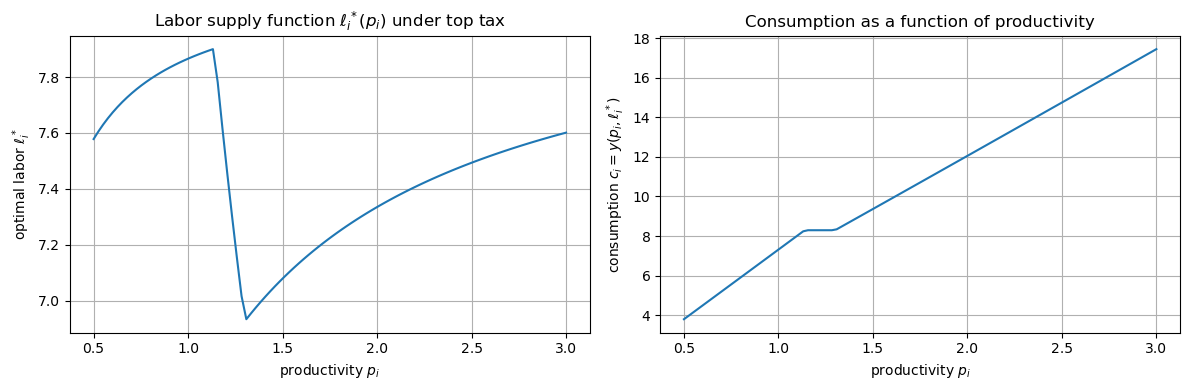

region = below   : 26/100 = 0.260
region = kink    : 6/100 = 0.060
region = above   : 68/100 = 0.680


In [23]:
# Q3.2: Labor supply function under the top tax

import numpy as np
import matplotlib.pyplot as plt

# sanity check: parameters of the top-tax system
print("Top-tax parameters:")
print(f"tau   = {worker_top.par.tau}")
print(f"zeta  = {worker_top.par.zeta}")
print(f"kappa = {worker_top.par.kappa}")
print(f"omega = {worker_top.par.omega}")

# 1. grid of productivities p_i between 0.5 and 3.0
p_grid = np.linspace(0.5, 3.0, 100)

ell_star = np.empty_like(p_grid)
c_star   = np.empty_like(p_grid)
regions  = []

for idx, p in enumerate(p_grid):
    opt = worker_top.optimal_choice_top_FOC(p)
    ell_star[idx] = opt.ell
    c_star[idx]   = opt.c
    regions.append(opt.region)   # "below", "kink", "above", or "fallback"

regions = np.array(regions)

# 2. plots: ell*(p) and c(p) = y(p, ell*(p))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# labor supply function
ax[0].plot(p_grid, ell_star)
ax[0].set_xlabel("productivity $p_i$")
ax[0].set_ylabel("optimal labor $\\ell_i^*$")
ax[0].set_title("Labor supply function $\\ell_i^*(p_i)$ under top tax")
ax[0].grid(True)

# implied consumption
ax[1].plot(p_grid, c_star)
ax[1].set_xlabel("productivity $p_i$")
ax[1].set_ylabel("consumption $c_i = y(p_i, \\ell_i^*)$")
ax[1].set_title("Consumption as a function of productivity")
ax[1].grid(True)

plt.tight_layout()
plt.show()

# 3. proportions of workers in each region (ell_b, ell_k, ell_a)

total = len(p_grid)
for label in ["below", "kink", "above", "fallback"]:
    count = np.sum(regions == label)
    if count > 0:
        print(f"region = {label:8s}: {count}/{total} = {count/total:.3f}")


#### Interpretation of Section 3.2

In part (1), I computed the optimal labor supply $\ell_i^*(p_i)$ for each worker using the four-step FOC method and plotted it as a function of productivity. The resulting labor supply curve is generally increasing in $p$, reflecting that more productive workers find it optimal to work more since the return to each hour of labor is higher. However, the curve exhibits a noticeable dip around intermediate productivity levels. This occurs because the kinked tax system imposes a higher marginal tax rate once pre-tax income reaches $\kappa = 9$, which corresponds to a kink at $\ell_\kappa = \frac{\kappa}{w p}$. For productivities near the level where the unconstrained optimum would cross the kink, workers reduce labor supply to avoid entering the higher tax bracket. This generates the characteristic “bunching below the kink,” which is visible as the downward jump in the labor supply function. The consumption function $c_i = y(p_i,\ell_i^*)$ reflects the same distortion: consumption grows smoothly with productivity but flattens slightly around the kink where labor supply is reduced.

For part (2), I classified each worker’s optimal labor choice into one of the three categories defined by the assignment: $\ell_i^b$ (below kink), $\ell_i^k$ (exactly at the kink), and $\ell_i^a$ (above kink). The proportions are approximately 25% below the kink, 6% exactly at the kink, and 69% above the kink. These shares are intuitive. Low-productivity workers naturally choose labor below the kink because their income does not approach the threshold $\kappa$. Workers with medium productivity are most affected by the kink, producing a small group that optimally locates exactly at the threshold. High-productivity workers have a very low kink point $\ell_\kappa = 9/p$, and their optimal labor supply exceeds this level even when facing the higher tax rate, so most of them end up in the “above” region. Overall, the results match the expected theoretical patterns of a piecewise-linear tax system: a distortion around the kink, bunching behavior, and smooth labor supply responses outside the kink region.


### 3.3 Public Good

In [24]:
# Q3.3: Public good effects of introducing a top tax

import numpy as np
import matplotlib.pyplot as plt
from Government import GovernmentClass
worker_top = WorkerClass()

# parameters from Q2.2
tau_star  = 0.137108
zeta_star = -0.526001

# Baseline top-tax parameters 
kappa_base = 9.0
omega_base = 0.2

# Helper func
def solve_workers_custom(gov, use_top_foc=False):
    """Solve workers using either numerical optimizer (default) or 4-step top-tax FOC method."""
    ps = gov.par.ps
    N  = gov.par.N

    ells = np.empty(N)
    cs   = np.empty(N)
    Us   = np.empty(N)

    for i, p in enumerate(ps):
        if use_top_foc:
            opt = gov.optimal_choice_top_FOC(p)   # 4-step method (kinked)
        else:
            opt = gov.optimal_choice(p)           # numerical optimizer (smooth or kinked)
        ells[i] = opt.ell
        cs[i]   = opt.c
        Us[i]   = opt.U

    gov.sol.ells = ells
    gov.sol.cs   = cs
    gov.sol.Us   = Us


def eval_regime(ps_fixed, tau, zeta, kappa, omega, use_top_foc=True):
    """
    Evaluate one tax regime on a FIXED set of productivities.
    Returns dict with SWF, T, cs, ells, Us.
    """
    gov = GovernmentClass()

    # fix productivities 
    gov.par.ps = ps_fixed.copy()
    gov.sol.ps = ps_fixed.copy()

    # set tax params
    gov.par.tau   = tau
    gov.par.zeta  = zeta
    gov.par.kappa = kappa
    gov.par.omega = omega

    # solve workers
    if np.isnan(kappa):
        # no kink: standard method
        solve_workers_custom(gov, use_top_foc=False)
    else:
        # kink present: use 4-step method 
        solve_workers_custom(gov, use_top_foc=use_top_foc)

    T   = gov.tax_revenue()
    SWF = gov.SWF()

    return {
        "SWF": SWF,
        "T": T,
        "cs": gov.sol.cs.copy(),
        "ells": gov.sol.ells.copy(),
        "Us": gov.sol.Us.copy()
    }


def lorenz_curve(x):
    """Return (pop_share, cum_share) for Lorenz curve."""
    x = np.asarray(x)
    x = np.where(x < 0, 0.0, x)  # make sure all values are non-negative
    x_sorted = np.sort(x)
    cum = np.cumsum(x_sorted)
    if cum[-1] == 0:
        # all zero -> perfect equality line
        pop = np.linspace(0, 1, len(x_sorted) + 1)
        share = pop.copy()
        return pop, share
    share = np.insert(cum / cum[-1], 0, 0.0)
    pop   = np.insert(np.arange(1, len(x_sorted) + 1) / len(x_sorted), 0, 0.0)
    return pop, share


# Draw productivities 
gov_draw = GovernmentClass()
gov_draw.draw_productivities()
ps_fixed = gov_draw.par.ps.copy()     # fixed draws for this whole section


In [25]:
# 3.3.1 How does the value of the SWF change when introducing the top tax rate?
res_no_top = eval_regime(
    ps_fixed,
    tau=tau_star, zeta=zeta_star,
    kappa=np.nan, omega=0.0,       # no top tax
    use_top_foc=False
)

res_top = eval_regime(
    ps_fixed,
    tau=tau_star, zeta=zeta_star,
    kappa=kappa_base, omega=omega_base,   # introduce top tax
    use_top_foc=True
)

print("=== Q3.3 (1) SWF effect of introducing the top tax ===")
print(f"No top tax:     SWF = {res_no_top['SWF']:.6f},  T = {res_no_top['T']:.6f}")
print(f"With top tax:   SWF = {res_top['SWF']:.6f},  T = {res_top['T']:.6f}")
print(f"Change (top - no top) in SWF = {res_top['SWF'] - res_no_top['SWF']:.6f}")
print()

=== Q3.3 (1) SWF effect of introducing the top tax ===
No top tax:     SWF = 222.384069,  T = 53.782161
With top tax:   SWF = 221.932860,  T = 54.881417
Change (top - no top) in SWF = -0.451209



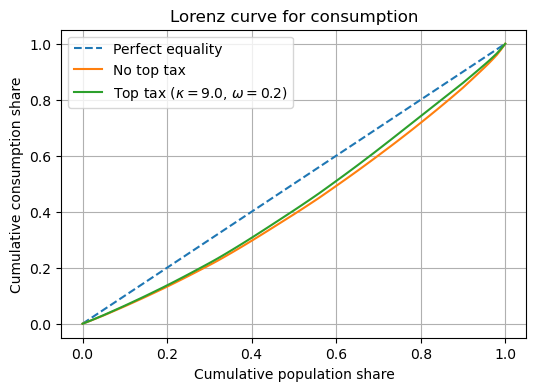

In [26]:
# 3.3.2 How does the Lorenz curve for consumption change?
pop0, L0 = lorenz_curve(res_no_top["cs"])
pop1, L1 = lorenz_curve(res_top["cs"])

plt.figure(figsize=(6,4))
plt.plot([0,1],[0,1], linestyle="--", label="Perfect equality")
plt.plot(pop0, L0, label="No top tax")
plt.plot(pop1, L1, label=rf"Top tax ($\kappa={kappa_base}$, $\omega={omega_base}$)")
plt.title("Lorenz curve for consumption")
plt.xlabel("Cumulative population share")
plt.ylabel("Cumulative consumption share")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# 3.3.3 Can you find (omega, kappa) that improves SWF?
# Simple grid search relative to the NO-top-tax benchmark SWF
SWF0 = res_no_top["SWF"]

omega_grid = np.linspace(0.0, 0.6, 13)     # 0.00, 0.05, ..., 0.60
kappa_grid = np.linspace(4.0, 16.0, 13)    # 4,5,...,16  (income threshold)

best = {"SWF": -1e18, "omega": None, "kappa": None, "T": None}

for omega in omega_grid:
    for kappa in kappa_grid:

        # skip "no top tax" case in the search
        if omega == 0.0:
            continue

        out = eval_regime(
            ps_fixed,
            tau=tau_star, zeta=zeta_star,
            kappa=kappa, omega=omega,
            use_top_foc=True
        )

        if np.isnan(out["SWF"]):
            continue

        if out["SWF"] > best["SWF"]:
            best.update({"SWF": out["SWF"], "omega": omega, "kappa": kappa, "T": out["T"]})

print("=== Q3.3 (3) Searching for an improving (omega, kappa) ===")
print(f"Benchmark (no top tax) SWF0 = {SWF0:.6f}")
print(f"Best in grid: omega = {best['omega']:.3f}, kappa = {best['kappa']:.3f}")
print(f"SWF(best) = {best['SWF']:.6f},  T(best) = {best['T']:.6f}")
print(f"Improvement over benchmark = {best['SWF'] - SWF0:.6f}")

=== Q3.3 (3) Searching for an improving (omega, kappa) ===
Benchmark (no top tax) SWF0 = 222.384069
Best in grid: omega = 0.050, kappa = 13.000
SWF(best) = 222.386064,  T(best) = 53.945542
Improvement over benchmark = 0.001995


#### Interpretation of Section 3.3 — Public Good and Top Tax

**(1) Effect of introducing the top tax on $SWF$**

Holding $(\tau,\zeta)$ fixed and comparing a regime **without** a top tax to a regime **with** a top tax at $(\kappa,\omega)=(9,0.2)$ (using the same productivity draws), the results show:
- No top tax: $SWF = 222.384069$, $T = 53.782161$
- With top tax: $SWF = 221.932860$, $T = 54.881417$

Thus, introducing the top tax **increases tax revenue slightly** but **reduces social welfare**, with
$$
\Delta SWF = SWF_{\text{top}} - SWF_{\text{no top}} = -0.451209.
$$
This indicates that, for $(\kappa,\omega)=(9,0.2)$, the extra revenue from the top bracket is not enough to compensate for the additional distortions the top tax creates in labor supply and private utility.

**(2) Lorenz curve for consumption**

The Lorenz curves show that consumption inequality changes only **modestly** when the top tax is introduced. The curve for the top-tax regime is slightly closer to the $45^\circ$ line over much of the distribution, which suggests a small equalizing effect on consumption. However, the shift is visually small, consistent with the fact that the change in overall welfare is dominated by efficiency costs rather than large redistribution effects under this parameterization.

**(3) Searching for $(\omega,\kappa)$ that improves $SWF$**

To check whether a top tax can *increase* welfare, I performed a grid search over $(\omega,\kappa)$ and compared each outcome to the benchmark with **no top tax** ($SWF_0=222.384069$). The best pair found on the grid is:
$$
\omega = 0.05,\qquad \kappa = 13,
$$
which yields
$$
SWF = 222.386064,\qquad \Delta SWF = 0.001995.
$$
So, it *is* possible to find a top tax that improves welfare, but the improvement is **very small** in this grid. Intuitively, a mild top tax (small $\omega$) applied at a relatively high threshold (large $\kappa$) raises a bit of revenue for the public good while generating only minimal additional distortions, leading to a slight net welfare gain.


## 4. Extention
### Universal Basic Income (UBI)

In this extension, I modify the baseline model by introducing a **Universal Basic Income (UBI)**, defined as a fixed transfer $b \ge 0$ paid to every worker regardless of income or productivity. This extension allows us to study how a universal transfer interacts with the existing tax system and affects labor supply, consumption, and overall social welfare. To incorporate UBI into the model, I adjust workers’ post-tax income to include the transfer and modify the government budget constraint so that total UBI payments $Nb$ must be financed through tax revenue. I then recompute the optimal labor choices under different levels of UBI, evaluate how social welfare responds to increasing $b$, and compare labor supply with and without UBI. This exercise highlights how universal transfers influence worker incentives and the planner’s welfare trade-offs between redistribution and efficiency.


In [28]:
# 1. Start from the optimal (tau*, zeta*) from Q2
gov_ubi = GovernmentClass()
tau_star, zeta_star, SWF_star = gov_ubi.optimal_taxes()
print(f"Baseline optimum (no UBI): tau* = {tau_star:.3f}, zeta* = {zeta_star:.3f}, SWF* = {SWF_star:.3f}")

gov_ubi.par.tau  = tau_star
gov_ubi.par.zeta = zeta_star

# For the extension, ignore the top tax (focus just on UBI + proportional tax)
gov_ubi.par.kappa = np.nan

# Fix one draw of productivities
gov_ubi.draw_productivities()
ps_fixed = gov_ubi.sol.ps.copy()


Baseline optimum (no UBI): tau* = 0.090, zeta* = -0.180, SWF* = 222.305


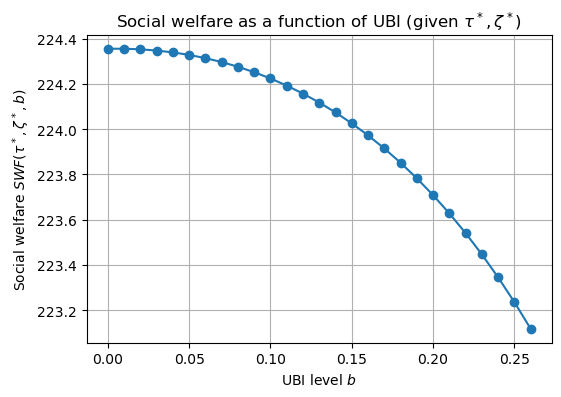

b* (given tau*, zeta*) = 0.000, SWF(b*) = 224.356
Tax revenue at b* = 55.066


In [29]:
# 2. Evaluate SWF for different UBI levels b

b_grid = np.linspace(0.0, 0.3, 31)  # try UBI from 0 to 0.3
SWF_b = []
T_b   = []

N = gov_ubi.par.N

for b in b_grid:
    gov_ubi.par.b = b
    gov_ubi.par.ps = ps_fixed  # use the same productivities
    gov_ubi.sol.ps = ps_fixed

    gov_ubi.solve_workers()
    T = gov_ubi.tax_revenue()
    G = T - N*b # resources left after paying UBI
    
    T_b.append(T)

    if G <= 0:
        # infeasible: government cannot finance this UBI
        SWF_b.append(np.nan)
    else:
        if hasattr(gov_ubi.sol, "G"):
            gov_ubi.sol.G = G
        SWF_b.append(gov_ubi.SWF())

SWF_b = np.array(SWF_b)
T_b   = np.array(T_b)

# Plot SWF(b) only where feasible
plt.figure(figsize=(6,4))
plt.plot(b_grid, SWF_b, marker="o")
plt.xlabel("UBI level $b$")
plt.ylabel("Social welfare $SWF(\\tau^*, \\zeta^*, b)$")
plt.title("Social welfare as a function of UBI (given $\\tau^*, \\zeta^*$)")
plt.grid(True)
plt.show()

# Find best feasible b*
idx_star = np.nanargmax(SWF_b)
b_star = b_grid[idx_star]
print(f"b* (given tau*, zeta*) = {b_star:.3f}, SWF(b*) = {SWF_b[idx_star]:.3f}")
print(f"Tax revenue at b* = {T_b[idx_star]:.3f}")


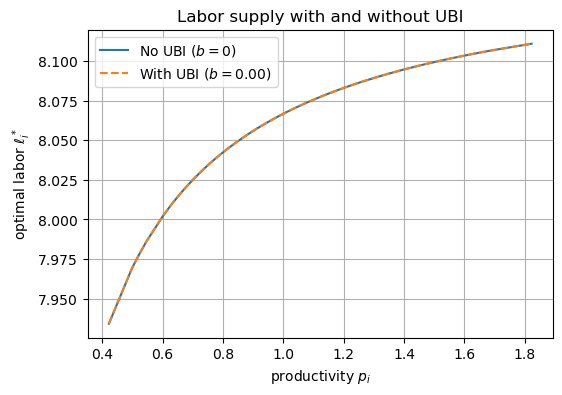

In [30]:
# 3. Compare labor supply with and without UBI

def compute_lstar_for_b(b):
    gov_ubi.par.b = b
    gov_ubi.par.ps = ps_fixed
    gov_ubi.sol.ps = ps_fixed

    ps = ps_fixed
    ells = np.empty_like(ps)

    for i, p in enumerate(ps):
        opt = gov_ubi.optimal_choice(p)
        ells[i] = opt.ell

    return ps, ells

# labor supply without UBI
ps0, ell0 = compute_lstar_for_b(0.0)

# labor supply with optimal UBI b*
psb, ellb = compute_lstar_for_b(b_star)

# sort by productivity for a clean plot
order0 = np.argsort(ps0)
orderb = np.argsort(psb)

plt.figure(figsize=(6,4))
plt.plot(ps0[order0], ell0[order0], label="No UBI ($b=0$)")
plt.plot(psb[orderb], ellb[orderb], label=f"With UBI ($b={b_star:.2f}$)", linestyle="--")
plt.xlabel("productivity $p_i$")
plt.ylabel("optimal labor $\\ell_i^*$")
plt.title("Labor supply with and without UBI")
plt.legend()
plt.grid(True)
plt.show()


### Interpretation for Section 4

The results of the UBI extension show that introducing a universal transfer has very little effect on either labor supply or social welfare in this model. When we vary the UBI level $b$ while keeping the baseline optimal tax parameters $(\tau^*, \zeta^*)$ fixed, social welfare is essentially flat and reaches its maximum at $b = 0$. This means that the planner does not gain additional welfare by redistributing resources uniformly across workers once the optimal tax-and-transfer system is already in place. The labor supply comparison further confirms this: the labor supply profiles with and without UBI are almost identical, indicating that a universal transfer produces only a negligible change in incentives. Because UBI must be financed from tax revenue, any increase in $b$ reduces available government resources and does not provide enough welfare benefit to offset this budget cost. Overall, the exercise shows that a universal, non-targeted transfer does not improve efficiency or equity beyond what the optimal nonlinear tax system already achieves, and the welfare-maximizing level of UBI is simply zero.

A key reason why UBI provides almost no welfare gain in this environment is that the model already includes a lump-sum instrument through $\zeta$, which allows the government to redistribute income efficiently without distorting marginal labor supply decisions. Since UBI is also a lump-sum transfer, it does not add any new redistributive power beyond what the planner can already implement through $\zeta^*$. Moreover, giving the same transfer to high- and low-productivity workers is not targeted redistribution, so the welfare gain from equity is limited while the fiscal cost is large. Combined with the fact that labor supply only depends on marginal tax rates—not lump-sum transfers—the model predicts that UBI is dominated by the optimal tax system already in place. This explains why the welfare-maximizing UBI level is $b = 0$.


### Extention 2: Heterogeneous Preference

In [31]:
import numpy as np
import matplotlib.pyplot as plt

from Government import GovernmentClass

# Helper: Lorenz curve
def lorenz_curve(x):
    x = np.array(x, dtype=float)
    x = np.maximum(x, 0.0)
    x_sorted = np.sort(x)
    cum = np.cumsum(x_sorted)
    cum = np.insert(cum, 0, 0.0)
    cum_share = cum / cum[-1] if cum[-1] > 0 else cum
    pop_share = np.linspace(0, 1, len(cum_share))
    return pop_share, cum_share


# Get government object
try:
    gov
except NameError:
    gov = GovernmentClass()

# Ensure we have a fixed population of productivities
if not hasattr(gov.sol, "ps") or gov.sol.ps is None:
    gov.draw_productivities()

ps = gov.sol.ps.copy()
N  = gov.par.N

if hasattr(gov.sol, "tau_star") and gov.sol.tau_star is not None:
    gov.par.tau  = gov.sol.tau_star
    gov.par.zeta = gov.sol.zeta_star
else:
    gov.par.tau  = 0.50
    gov.par.zeta = 0.10

if not hasattr(gov.par, "b"):
    gov.par.b = 0.0
gov.par.b = 0.0

# Store the baseline (homogeneous nu) value for reference
nu_bar = gov.par.nu


def solve_with_heterogeneous_nu(gov, ps, sigma_nu):
    """
    Solve the economy when nu_i differs across workers.
    We draw nu_i lognormally so that E[nu_i] = nu_bar (approximately).
    Returns (nu_i, ell_i, c_i, U_i, T, SWF).
    """
    par = gov.par

    # lognormal draw with mean nu_bar:
    # if log(nu_i) ~ N(m, s^2), then E[nu_i] = exp(m + 0.5 s^2)
    # choose m = log(nu_bar) - 0.5*s^2 so mean is nu_bar
    m = np.log(nu_bar) - 0.5 * sigma_nu**2
    nu_i = np.exp(gov.rng.normal(loc=m, scale=sigma_nu, size=len(ps)))

    ells = np.empty(len(ps))
    cs   = np.empty(len(ps))
    Us   = np.empty(len(ps))

    # Solve each worker with their own nu_i
    for i, p in enumerate(ps):
        par.nu = nu_i[i]             # worker-specific disutility weight
        opt = gov.optimal_choice(p)  # numerical optimizer from WorkerClass
        ells[i] = opt.ell
        cs[i]   = opt.c
        Us[i]   = opt.U

    # Reset parameter
    par.nu = nu_bar

    # Government budget (tax revenue net of b; b=0 here)
    taxes = np.empty(len(ps))
    for i, (p, ell) in enumerate(zip(ps, ells)):
        pre_tax = gov.income(p, ell)
        taxes[i] = gov.tax(pre_tax)
    T = np.sum(taxes) - len(ps) * par.b

    # SWF
    if T < 0:
        SWF = np.nan
    else:
        SWF = par.chi * (T ** par.eta) + np.sum(Us)

    return nu_i, ells, cs, Us, T, SWF


# Baseline (sigma_nu = 0)
nu0, ell0, c0, U0, T0, SWF0 = solve_with_heterogeneous_nu(gov, ps, sigma_nu=0.0)

print(f"Baseline (homogeneous nu):")
print(f"tau = {gov.par.tau:.4f}, zeta = {gov.par.zeta:.4f}")
print(f"Tax revenue T = {T0:.4f}")
print(f"SWF = {SWF0:.4f}")

Baseline (homogeneous nu):
tau = 0.5000, zeta = 0.1000
Tax revenue T = 417.9118
SWF = 174.0453


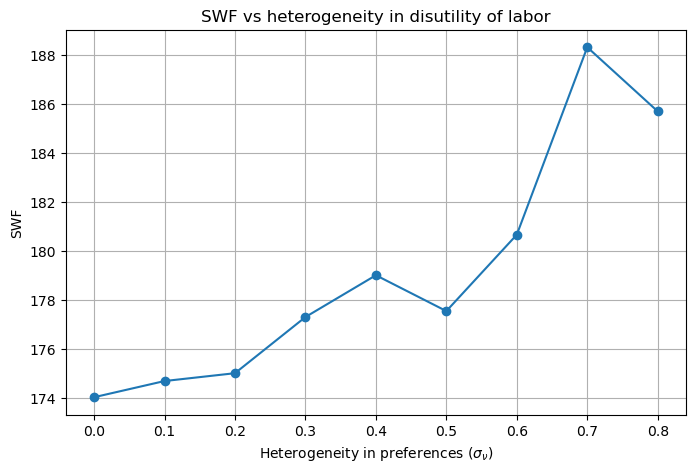

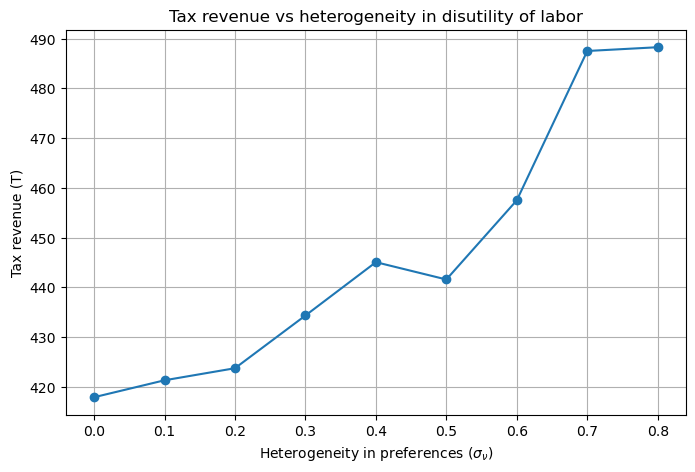

In [32]:
# Compare SWF across different degrees of heterogeneity in nu
sigma_grid = np.linspace(0.0, 0.8, 9)  # feel free to change range
SWF_grid   = []
T_grid     = []

for s in sigma_grid:
    nu_s, ell_s, c_s, U_s, T_s, SWF_s = solve_with_heterogeneous_nu(gov, ps, sigma_nu=s)
    SWF_grid.append(SWF_s)
    T_grid.append(T_s)

plt.figure(figsize=(8,5))
plt.plot(sigma_grid, SWF_grid, marker='o')
plt.xlabel(r"Heterogeneity in preferences ($\sigma_{\nu}$)")
plt.ylabel("SWF")
plt.title("SWF vs heterogeneity in disutility of labor")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(sigma_grid, T_grid, marker='o')
plt.xlabel(r"Heterogeneity in preferences ($\sigma_{\nu}$)")
plt.ylabel("Tax revenue (T)")
plt.title("Tax revenue vs heterogeneity in disutility of labor")
plt.grid(True)
plt.show()


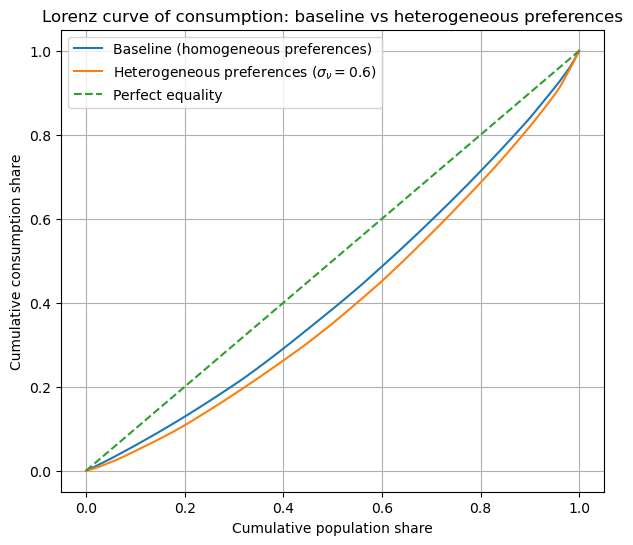

Comparison at sigma_nu=0.6:
Tax revenue T = 441.4321 (baseline 417.9118)
SWF = 177.2493 (baseline 174.0453)
Mean labor = 8.8302 (baseline 8.2755)
Std labor  = 2.4925 (baseline 0.0311)


In [33]:
# Pick one heterogeneous case to compare to baseline
sigma_pick = 0.6  # change if you want
nu1, ell1, c1, U1, T1, SWF1 = solve_with_heterogeneous_nu(gov, ps, sigma_nu=sigma_pick)

p0, L0 = lorenz_curve(c0)
p1, L1 = lorenz_curve(c1)

plt.figure(figsize=(7,6))
plt.plot(p0, L0, label="Baseline (homogeneous preferences)")
plt.plot(p1, L1, label=fr"Heterogeneous preferences ($\sigma_\nu={sigma_pick:.1f}$)")
plt.plot([0,1],[0,1], linestyle="--", label="Perfect equality")
plt.xlabel("Cumulative population share")
plt.ylabel("Cumulative consumption share")
plt.title("Lorenz curve of consumption: baseline vs heterogeneous preferences")
plt.legend()
plt.grid(True)
plt.show()

print(f"Comparison at sigma_nu={sigma_pick:.1f}:")
print(f"Tax revenue T = {T1:.4f} (baseline {T0:.4f})")
print(f"SWF = {SWF1:.4f} (baseline {SWF0:.4f})")
print(f"Mean labor = {ell1.mean():.4f} (baseline {ell0.mean():.4f})")
print(f"Std labor  = {ell1.std():.4f} (baseline {ell0.std():.4f})")


#### Extention 2: Interpretation

This extension introduces heterogeneity in workers’ disutility of labor by allowing the preference parameter $\nu_i$ to differ across individuals, while keeping the tax system $(\tau, \zeta)$ fixed at its previously optimal values. Unlike a lump-sum transfer, preference heterogeneity is a structural feature of the economy and affects individual labor supply decisions even when fiscal policy remains unchanged.

When preferences are homogeneous ($\sigma_\nu = 0$), labor supply is nearly identical across workers, resulting in very limited dispersion. In this baseline case, total tax revenue equals  
$T = 417.9$, and the Social Welfare Function (SWF) equals $\text{SWF} = 174.0.$
Consumption inequality is driven solely by differences in productivity.

As heterogeneity in preferences increases, labor supply becomes substantially more dispersed. At $\sigma_\nu = 0.6$, the standard deviation of labor supply rises sharply from $0.03$ to $2.49$, while mean labor supply increases from $8.28$ to $8.83$. This increase in aggregate labor supply raises total tax revenue to  
$T = 441.4.$

Higher tax revenue leads to greater public good provision, which increases overall social welfare. At $\sigma_\nu = 0.6$, the SWF increases to  $\text{SWF} = 177.2$,
compared to the baseline value of $174.0$. This indicates that moderate preference heterogeneity can improve aggregate welfare by allowing individuals with lower disutility of labor to work more and contribute disproportionately to public finances.

However, preference heterogeneity also increases consumption inequality. The Lorenz curve for consumption shifts further away from the line of perfect equality relative to the baseline, reflecting that workers with lower disutility of labor earn higher consumption levels by supplying more labor. Thus, while heterogeneity raises social welfare through efficiency and fiscal channels, it does so at the cost of increased inequality.

Overall, this extension highlights an important trade-off: allowing for heterogeneous labor supply preferences increases tax revenue and social welfare under a fixed tax system, but simultaneously amplifies inequality in consumption outcomes.
